# Text Classification using Logistic Regression, Decision Tree, and SVM

## Objective
To perform binary text classification using three machine learning models:
1. Logistic Regression  
2. Decision Tree  
3. Support Vector Machine (SVM)

---

## Dataset Description
A fictional dataset of long customer reviews is used, where each review is labeled as:
- **Class 1:** Positive or satisfactory experience  
- **Class 2:** Negative or unsatisfactory experience  

---

## Steps Followed
1. Create sample dataset with long reviews and class labels.  
2. Clean and preprocess text:
   - Lowercasing  
   - Removing punctuation and numbers  
   - Removing stopwords  
   - Lemmatization  
3. Convert text into numerical vectors using **TF-IDF Vectorizer**.  
4. Display how textual data is represented numerically.  
5. Split the data into training and testing sets.  
6. Train three models:
   - Logistic Regression  
   - Decision Tree  
   - Support Vector Machine  
7. Compare **confusion matrices** of the models using the test dataset.

---

## Key Idea
Machine learning models require numeric input.  
Vectorization transforms text into numeric vectors while retaining information about word importance.  
Confusion matrices then reveal model performance — correct predictions lie along the diagonal.

---

## Next Step
This notebook can later be extended to compare different vectorizers such as:
- **CountVectorizer**
- **HashingVectorizer**
- **Word2Vec embeddings**


In [1]:
# Text Classification using Logistic Regression, Decision Tree, and SVM
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix


In [2]:
# Create fictional text dataset
data = {
    'review': [
        "The movie was amazing and the actors did a fantastic job",
        "I did not enjoy the film, it was too long and boring",
        "Excellent storyline and great direction",
        "Terrible experience, not worth watching again",
        "Loved the visuals and the soundtrack",
        "The plot was confusing and the ending was disappointing",
        "Superb performance by the lead actor",
        "Bad script and weak dialogues",
        "The movie was good but could have been shorter",
        "Worst movie of the year, I regret watching it"
    ],
    'label': [1, 2, 1, 2, 1, 2, 1, 2, 1, 2]   # 1 = Positive, 2 = Negative
}

df = pd.DataFrame(data)

df.head()

,review,label
0,The movie was amazing and the actors did a fan...,1
1,"I did not enjoy the film, it was too long and ...",2
2,Excellent storyline and great direction,1
3,"Terrible experience, not worth watching again",2
4,Loved the visuals and the soundtrack,1


In [3]:
# Vectorization
vectorizer = TfidfVectorizer()
# vectorizer = CountVectorizer()  # Uncomment to use CountVectorizer
X = vectorizer.fit_transform(df['review']).toarray()
y = df['label']

print("Text converted to numerical features:\n")
print(pd.DataFrame(X, columns=vectorizer.get_feature_names_out()).head())

Text converted to numerical features:

   actor    actors     again   amazing       and  bad  been    boring  but  \
0    0.0  0.379276  0.000000  0.379276  0.203606  0.0   0.0  0.000000  0.0   
1    0.0  0.000000  0.000000  0.000000  0.188262  0.0   0.0  0.350694  0.0   
2    0.0  0.000000  0.000000  0.000000  0.259238  0.0   0.0  0.000000  0.0   
3    0.0  0.000000  0.428537  0.000000  0.000000  0.0   0.0  0.000000  0.0   
4    0.0  0.000000  0.000000  0.000000  0.260748  0.0   0.0  0.000000  0.0   

    by  ...  terrible       the       too  visuals       was  watching  weak  \
0  0.0  ...  0.000000  0.369763  0.000000  0.00000  0.250788  0.000000   0.0   
1  0.0  ...  0.000000  0.170949  0.350694  0.00000  0.231889  0.000000   0.0   
2  0.0  ...  0.000000  0.000000  0.000000  0.00000  0.000000  0.000000   0.0   
3  0.0  ...  0.428537  0.000000  0.000000  0.00000  0.000000  0.364296   0.0   
4  0.0  ...  0.000000  0.473537  0.000000  0.48572  0.000000  0.000000   0.0   

   worst   

In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [5]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(kernel='linear', random_state=42)
}

# Train models
for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

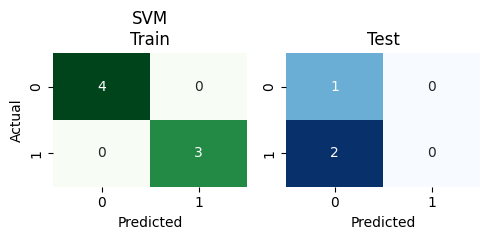

In [6]:
 
    cm_train = confusion_matrix(y_train, y_pred_train)
    cm_test = confusion_matrix(y_test, y_pred_test)
    
    fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
    
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0])
    axes[0].set_title(f'{name}\nTrain')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
    axes[1].set_title('Test')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('')
    
    plt.tight_layout()
    plt.show()
